# 09_GridSearchCV.ipynb

# Section 1 — Introduction

GridSearchCV is one of the **most important tools in scikit-learn**. It automates the process of finding the **best hyperparameters** for a machine learning model using **Cross Validation**.

---

# What is GridSearchCV?

**GridSearchCV** systematically tries **all possible combinations of specified hyperparameters**, evaluates each combination using **Cross Validation**, and returns the one with the best performance.

Instead of manually testing different parameter values, GridSearchCV does it automatically.

---

# Why Do We Need GridSearchCV?

Suppose you're training Logistic Regression.

You don't know the best values for:

* `C`
* `solver`
* `penalty`
* `max_iter`

You could try them manually:

```python
model = LogisticRegression(C=0.1)

model = LogisticRegression(C=1)

model = LogisticRegression(C=10)
```

This quickly becomes tedious.

GridSearchCV automates the process.

---

# Manual Search

Suppose you want to test:

```text
C

0.1

1

10
```

You manually train

```text
Model 1

↓

Evaluate

↓

Model 2

↓

Evaluate

↓

Model 3

↓

Evaluate

↓

Compare
```

Simple for one parameter.

---

Now add another parameter.

```text
Solver

lbfgs

liblinear
```

Now you have

```text
3 × 2 = 6 models
```

Add

```text
Penalty

l2

None
```

Now

```text
3 × 2 × 2 = 12 models
```

This grows very quickly.

---

# GridSearchCV Solution

Instead of training manually,

you define a **parameter grid**.

Example

```python
param_grid = {
    "classifier__C": [0.1, 1, 10],

    "classifier__solver": [
        "lbfgs",
        "liblinear"
    ]
}
```

GridSearchCV automatically trains

```text
C=0.1
Solver=lbfgs

↓

C=0.1
Solver=liblinear

↓

C=1
Solver=lbfgs

↓

C=1
Solver=liblinear

↓

...

Until every combination is tested.
```

---

# Why "Grid" Search?

Imagine every parameter forms one axis.

```text
             Solver

        lbfgs     liblinear

C=0.1      □            □

C=1        □            □

C=10       □            □
```

Every square represents **one model**.

GridSearchCV evaluates **every square**.

Hence the name **Grid Search**.

---

# Mathematical Intuition

Suppose

```text
C

3 values

Solver

2 values

Penalty

2 values
```

Total models

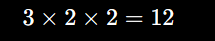

If using **5-fold Cross Validation**

Each model is trained

```text
5 times
```

Total model training operations

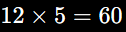

This is why GridSearchCV can become computationally expensive.

---

# How Does GridSearchCV Work?

Suppose

```text
Parameter Grid

C

0.1

1

10

Solver

lbfgs

liblinear
```

Step 1

Train

```text
C=0.1

Solver=lbfgs
```

Perform **5-Fold Cross Validation**

↓

Average Accuracy

---

Step 2

Train

```text
C=0.1

Solver=liblinear
```

Again perform **5-Fold Cross Validation**

↓

Average Accuracy

---

Repeat until

```text
Every Combination

↓

Cross Validation

↓

Average Score
```

Finally,

```text
Choose Best Combination
```

---

# Relationship with Cross Validation

This is the most important concept.

GridSearchCV **uses Cross Validation internally**.

```text
Parameter Combination

↓

Cross Validation

↓

Mean Score

↓

Next Combination

↓

Cross Validation

↓

Mean Score

↓

Best Combination
```

So,

> **GridSearchCV = Hyperparameter Search + Cross Validation**

---

# Advantages

| Advantage                                     | Explanation                                  |
| --------------------------------------------- | -------------------------------------------- |
| Finds the best hyperparameters                | Tests all specified combinations             |
| Uses Cross Validation                         | More reliable than a single train-test split |
| Fully automated                               | No manual experimentation                    |
| Integrates with Pipelines                     | Prevents data leakage                        |
| Works with almost all scikit-learn estimators | Same interface across models                 |

---

# Disadvantages

| Disadvantage                   | Explanation                             |
| ------------------------------ | --------------------------------------- |
| Computationally expensive      | Trains many models                      |
| Slow for large parameter grids | Combinations grow rapidly               |
| Searches only specified values | Doesn't explore values outside the grid |

---

# When to Use

Use GridSearchCV when:

* Tuning hyperparameters.
* Comparing parameter combinations.
* Building the final version of a model.
* Working with Pipelines.

---

# When NOT to Use

Avoid GridSearchCV when:

* The parameter grid is extremely large (consider `RandomizedSearchCV`).
* You need very fast experimentation.
* The model itself takes a long time to train.

---

# Applications

| Model               | Common Hyperparameters Tuned                     |
| ------------------- | ------------------------------------------------ |
| Logistic Regression | `C`, `solver`, `penalty`                         |
| Linear Regression   | `fit_intercept`, `positive`                      |
| Random Forest       | `n_estimators`, `max_depth`, `min_samples_split` |
| SVM                 | `C`, `kernel`, `gamma`                           |
| KNN                 | `n_neighbors`, `weights`, `metric`               |

---

# Manual Tuning vs GridSearchCV

| Manual Tuning                    | GridSearchCV                          |
| -------------------------------- | ------------------------------------- |
| Try one combination at a time    | Tests every combination automatically |
| Easy to miss good settings       | Exhaustively searches the grid        |
| Time-consuming                   | Automated                             |
| Difficult with many parameters   | Handles multiple parameters naturally |
| Less reliable if using one split | Uses Cross Validation                 |

---

# Key Takeaways

* GridSearchCV automates **hyperparameter tuning**.
* It evaluates **every parameter combination** in the grid.
* Every combination is evaluated using **Cross Validation**.
* The combination with the **best average score** is selected.
* It works exceptionally well with **Pipelines**, preventing data leakage while tuning preprocessing and model parameters.

---

## ⭐ Connection to What You've Already Learned

Notice how the last three notebooks build on each other:

```text
Pipeline
      ↓
Cross Validation
      ↓
GridSearchCV
```

* **Pipeline** combines preprocessing and the model.
* **Cross Validation** evaluates a model reliably.
* **GridSearchCV** uses both to automatically find the best hyperparameters.

# 09_GridSearchCV.ipynb

# Section 2 — Import & Constructor

Just like `Cross Validation`, **GridSearchCV is not a machine learning model**.

It is a **meta-estimator** that wraps another estimator (or Pipeline), tries different hyperparameter combinations, evaluates them using Cross Validation, and selects the best one.

---

# Import

```python
from sklearn.model_selection import GridSearchCV
```

Usually you'll also import:

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
```

---

# Constructor

```python
GridSearchCV(
    estimator,
    param_grid,
    *,
    scoring=None,
    n_jobs=None,
    refit=True,
    cv=None,
    verbose=0,
    return_train_score=False
)
```

These are the parameters you'll use **90% of the time**.

---

# Important Parameters

| Parameter            | Default | Description                                   |
| -------------------- | ------- | --------------------------------------------- |
| `estimator`          | —       | Model or Pipeline to tune                     |
| `param_grid`         | —       | Dictionary containing parameters to search    |
| `scoring`            | `None`  | Metric used to compare parameter combinations |
| `cv`                 | `None`  | Cross-validation strategy                     |
| `refit`              | `True`  | Retrain the best model on the entire dataset  |
| `n_jobs`             | `None`  | Number of CPU cores                           |
| `verbose`            | `0`     | Prints training progress                      |
| `return_train_score` | `False` | Stores training scores for analysis           |

---

# 1. estimator ⭐⭐⭐⭐⭐

The estimator that GridSearchCV will tune.

Can be:

```python
LogisticRegression()
```

or

```python
RandomForestClassifier()
```

or

```python
Pipeline(...)
```

Example

```python
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression())
])
```

Then

```python
grid = GridSearchCV(
    estimator=pipe,
    ...
)
```

**Recommended:** Always use a `Pipeline` when preprocessing is required.

---

# 2. param_grid ⭐⭐⭐⭐⭐

The **most important parameter**.

It tells GridSearchCV:

> "Which hyperparameters should I try?"

---

## Syntax

```python
param_grid = {
    parameter_name: [list of values]
}
```

Example

```python
param_grid = {
    "classifier__C": [0.1, 1, 10]
}
```

GridSearchCV trains

```text
Model 1

C = 0.1

↓

Model 2

C = 1

↓

Model 3

C = 10
```

---

## Multiple Parameters

```python
param_grid = {

    "classifier__C":[0.1,1,10],

    "classifier__solver":[
        "lbfgs",
        "liblinear"
    ]
}
```

Grid becomes

```text
C=0.1 Solver=lbfgs

C=0.1 Solver=liblinear

C=1 Solver=lbfgs

C=1 Solver=liblinear

C=10 Solver=lbfgs

C=10 Solver=liblinear
```

Total

```text
3 × 2 = 6 models
```

---

## Why `classifier__C`?

Because the estimator is inside a Pipeline.

```python
Pipeline([
    ("scaler", StandardScaler()),

    ("classifier",
        LogisticRegression())
])
```

Pipeline parameter format

```text
step_name__parameter
```

Exactly the same as

```python
pipe.set_params(
    classifier__C=10
)
```

---

# 3. scoring ⭐⭐⭐⭐⭐

Specifies how models are compared.

Default

```python
None
```

Means

Use estimator's default `score()` method.

---

Classification examples

```python
scoring="accuracy"
```

```python
scoring="f1_macro"
```

Regression examples

```python
scoring="r2"
```

```python
scoring="neg_mean_squared_error"
```

---

# 4. cv ⭐⭐⭐⭐⭐

Specifies Cross Validation.

Most common

```python
cv=5
```

or

```python
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
```

Example

```python
grid = GridSearchCV(
    estimator=pipe,

    param_grid=param_grid,

    cv=cv
)
```

---

# 5. refit ⭐⭐⭐⭐

One of the most misunderstood parameters.

Default

```python
refit=True
```

Suppose

Grid Search finds

```text
Best Parameters

C=1

Solver=lbfgs
```

If

```python
refit=True
```

GridSearchCV automatically trains **one final model** using

* Entire dataset
* Best parameters

Then

```python
grid.predict(X_test)
```

works immediately.

---

If

```python
refit=False
```

Grid Search

* Finds best parameters

BUT

does **not** train the final model.

Then

```python
grid.predict()
```

will raise an error.

---

**Recommendation**

Always keep

```python
refit=True
```

unless you have a specific reason not to.

---

# 6. n_jobs ⭐⭐⭐

Controls CPU usage.

```python
n_jobs=None
```

One CPU core.

---

```python
n_jobs=-1
```

All CPU cores.

Recommended for Grid Search because many models are trained.

---

# 7. verbose ⭐⭐⭐

Prints progress.

```python
verbose=0
```

No output.

---

```python
verbose=2
```

Example

```text
Fitting 5 folds for each of 6 candidates

30 fits
```

Very useful for long-running searches.

---

# 8. return_train_score ⭐⭐

Default

```python
False
```

If

```python
True
```

stores both

* Training scores
* Validation scores

Useful for diagnosing overfitting.

Most beginners don't need it.

---

# Recommended Settings

For classification

```python
grid = GridSearchCV(
    estimator=pipe,

    param_grid=param_grid,

    scoring="accuracy",

    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),

    refit=True,

    n_jobs=-1,

    verbose=2
)
```

---

# Constructor Summary

| Parameter            | Importance |
| -------------------- | ---------- |
| `estimator`          | ⭐⭐⭐⭐⭐      |
| `param_grid`         | ⭐⭐⭐⭐⭐      |
| `scoring`            | ⭐⭐⭐⭐⭐      |
| `cv`                 | ⭐⭐⭐⭐⭐      |
| `refit`              | ⭐⭐⭐⭐       |
| `n_jobs`             | ⭐⭐⭐        |
| `verbose`            | ⭐⭐⭐        |
| `return_train_score` | ⭐⭐         |

---

# ⭐ Interview Questions

### Q1. What is `param_grid`?

**Answer:**

It is a dictionary that defines the hyperparameters and their candidate values that GridSearchCV should evaluate.

---

### Q2. Why do Pipeline parameter names contain `__`?

**Answer:**

The double underscore separates the **pipeline step name** from the **parameter name**, allowing GridSearchCV to tune parameters of estimators inside a Pipeline.

Example:

```python
"classifier__C"
```

---

### Q3. What does `refit=True` do?

**Answer:**

After finding the best hyperparameters using Cross Validation, GridSearchCV automatically retrains the estimator on the **entire dataset** using those best parameters, making it ready for prediction.


Good question.

If you set:

```python
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    return_train_score=True
)
```

then after fitting:

```python
grid.fit(X, y)
```

all the scores are stored in **`grid.cv_results_`**.

---

## 1. Validation Scores

Mean validation score:

```python
grid.cv_results_["mean_test_score"]
```

Example:

```python
array([0.95, 0.97, 0.96])
```

One value for each parameter combination.

---

Validation score for each fold:

```python
grid.cv_results_["split0_test_score"]

grid.cv_results_["split1_test_score"]

grid.cv_results_["split2_test_score"]
...
```

---

## 2. Training Scores (because `return_train_score=True`)

Mean training score:

```python
grid.cv_results_["mean_train_score"]
```

Example:

```python
array([0.98, 0.99, 1.00])
```

Training score for each fold:

```python
grid.cv_results_["split0_train_score"]

grid.cv_results_["split1_train_score"]

...

grid.cv_results_["split4_train_score"]
```

---

## 3. Parameter Values

```python
grid.cv_results_["params"]
```

Example:

```python
[
 {'classifier__C':0.1},
 {'classifier__C':1},
 {'classifier__C':10}
]
```

---

## 4. Complete Results

```python
grid.cv_results_.keys()
```

You'll see keys like:

```text
mean_fit_time
std_fit_time

mean_score_time
std_score_time

param_classifier__C
param_classifier__solver

params

split0_test_score
split1_test_score
...
split4_test_score

mean_test_score
std_test_score

rank_test_score

split0_train_score
...
mean_train_score
std_train_score
```

---

## Example

Suppose:

```python
param_grid = {
    "classifier__C": [0.1, 1, 10]
}
```

Then:

| C   | Mean Train Score | Mean Test Score |
| --- | ---------------: | --------------: |
| 0.1 |             0.97 |            0.95 |
| 1   |             0.99 |            0.97 |
| 10  |             1.00 |            0.96 |

You can access them as:

```python
print(grid.cv_results_["params"])

print(grid.cv_results_["mean_train_score"])

print(grid.cv_results_["mean_test_score"])
```

---

## ⭐ Most Useful Attributes (Remember These)

| Attribute              | Purpose                                         |
| ---------------------- | ----------------------------------------------- |
| `grid.best_score_`     | Best cross-validation score                     |
| `grid.best_params_`    | Best hyperparameters                            |
| `grid.best_estimator_` | Best trained model                              |
| `grid.cv_results_`     | Complete results of every parameter combination |

These four are the ones you'll use most often in practice and interviews.


# 09_GridSearchCV.ipynb

# Section 3 — Methods & Attributes

Unlike `Pipeline`, most of the useful information in `GridSearchCV` is available **after calling `fit()`**.

---

# Step 1

```python
grid.fit(X, y)
```

After this, all the following methods and attributes become available.

---

# Methods

## 1. fit() ⭐⭐⭐⭐⭐

Performs the entire Grid Search.

```python
grid.fit(X, y)
```

Internally

```text
Parameter Combination 1
↓

5-Fold Cross Validation
↓

Mean Score

↓

Parameter Combination 2

↓

5-Fold Cross Validation

↓

Mean Score

↓

...

↓

Best Parameters Found

↓

Refit Best Model (if refit=True)
```

Returns

```python
GridSearchCV object
```

---

## 2. predict() ⭐⭐⭐⭐⭐

Only works if

```python
refit=True
```

(default)

```python
y_pred = grid.predict(X_test)
```

Internally

```text
Best Estimator

↓

Predict
```

Notice

You don't write

```python
grid.best_estimator_.predict()
```

although you can.

Simply

```python
grid.predict()
```

works.

---

## 3. score()

Evaluate the **best model**.

```python
grid.score(X_test, y_test)
```

Example

```python
0.983
```

Equivalent to

```python
grid.best_estimator_.score(
    X_test,
    y_test
)
```

---

## 4. predict_proba()

If estimator supports probabilities.

```python
grid.predict_proba(X_test)
```

Returns

```python
[[0.98,0.02],
 [0.01,0.99],
 ...]
```

---

# Important Attributes ⭐⭐⭐⭐⭐

---

## 1. best_params_

Most asked interview question.

Returns

```python
Dictionary
```

Example

```python
grid.best_params_
```

Output

```python
{
 'classifier__C':1,

 'classifier__solver':'lbfgs'
}
```

Meaning

Grid Search found these parameters produced the best score.

---

## 2. best_score_

Returns

```text
Best Mean Cross Validation Score
```

Example

```python
grid.best_score_
```

Output

```text
0.983
```

Notice

This is **NOT**

Test accuracy.

It is

```text
Mean Cross Validation Score
```

---

## 3. best_estimator_

Returns

The **fully trained estimator**.

Example

```python
grid.best_estimator_
```

Output

```python
Pipeline(
    ...
)
```

Since

```python
refit=True
```

Grid Search automatically trained

the best pipeline

using

the **entire dataset**.

You can now use

```python
grid.best_estimator_.predict(X_test)
```

---

## 4. cv_results_ ⭐⭐⭐⭐⭐

Returns

Dictionary

containing

every result.

Example

```python
grid.cv_results_
```

---

### Mean Validation Scores

```python
grid.cv_results_[
    "mean_test_score"
]
```

Example

```python
array([
0.95,

0.97,

0.96
])
```

---

### Mean Training Scores

Requires

```python
return_train_score=True
```

Then

```python
grid.cv_results_[
    "mean_train_score"
]
```

---

### Standard Deviation

```python
grid.cv_results_[
    "std_test_score"
]
```

Shows

how much

scores vary

across folds.

---

### Parameter Values

```python
grid.cv_results_[
    "params"
]
```

Example

```python
[
 {'classifier__C':0.1},

 {'classifier__C':1},

 {'classifier__C':10}
]
```

---

### Ranking

```python
grid.cv_results_[
    "rank_test_score"
]
```

Example

```python
array([
3,

1,

2
])
```

Meaning

```text
Rank 1

↓

Best Model
```

---

# Useful Keys

| Key                | Description                        |
| ------------------ | ---------------------------------- |
| `mean_test_score`  | Mean validation score              |
| `std_test_score`   | Std. deviation of validation score |
| `mean_train_score` | Mean training score                |
| `std_train_score`  | Std. deviation of training score   |
| `params`           | Parameter combinations             |
| `rank_test_score`  | Ranking of parameter combinations  |

---

# Convert Results to DataFrame ⭐⭐⭐⭐

Very common.

```python
import pandas as pd

results = pd.DataFrame(
    grid.cv_results_
)

results.head()
```

Now

you can

sort

filter

save

analyze

the results easily.

---

# Example

```python
results[
[
"params",

"mean_test_score",

"std_test_score",

"rank_test_score"
]
]
```

Output

| Params | Mean Score |   Std | Rank |
| ------ | ---------: | ----: | ---: |
| C=0.1  |       0.95 |  0.01 |    3 |
| C=1    |       0.97 | 0.008 |    1 |
| C=10   |       0.96 | 0.009 |    2 |

---

# Complete Example

```python
grid.fit(X, y)

print(grid.best_params_)

print(grid.best_score_)

print(grid.best_estimator_)

results = pd.DataFrame(
    grid.cv_results_
)

print(
    results[
        [
            "params",
            "mean_test_score",
            "rank_test_score"
        ]
    ]
)
```

---

# Summary Table

## Methods

| Method            | Purpose                  |
| ----------------- | ------------------------ |
| `fit()`           | Run Grid Search          |
| `predict()`       | Predict using best model |
| `predict_proba()` | Probability predictions  |
| `score()`         | Evaluate best model      |

---

## Attributes

| Attribute         | Purpose                      |
| ----------------- | ---------------------------- |
| `best_params_`    | Best hyperparameters         |
| `best_score_`     | Best mean CV score           |
| `best_estimator_` | Best trained estimator       |
| `cv_results_`     | Complete Grid Search results |

---

# ⭐ Interview Questions

### Q1. What is the difference between `best_score_` and `score()`?

**Answer:**

* `best_score_` is the **best average cross-validation score** obtained during the grid search.
* `score()` evaluates the **best fitted estimator** on the dataset you pass (e.g., a test set).

---

### Q2. What does `best_estimator_` return?

**Answer:**

It returns the estimator (or pipeline) retrained on the **entire dataset** using the best hyperparameters, provided `refit=True`.

---

### Q3. Why is `cv_results_` useful?

**Answer:**

It stores the complete results of the grid search, including parameter combinations, mean and standard deviation of scores, rankings, and timing information. It is commonly converted into a pandas DataFrame for analysis.

---

This completes **Section 3 — Methods & Attributes**.
